# Flight Price Prediction
**Dataset:** Indian Airlines.csv  
**Target:** `price` (INR, not scaled)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

---
## Section 1 — Exploratory Data Analysis

In [2]:
df = pd.read_csv('../data/Indian Airlines.csv', index_col=0)
print('Shape:', df.shape)
print('\nDtypes:')
print(df.dtypes)

Shape: (300153, 11)

Dtypes:
airline              object
flight               object
source_city          object
departure_time       object
stops                object
arrival_time         object
destination_city     object
class                object
duration            float64
days_left             int64
price                 int64
dtype: object


In [3]:
print('Missing values:')
print(df.isnull().sum())
print('\nDuplicates:', df.duplicated().sum())

Missing values:
airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

Duplicates: 0


In [4]:
df.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


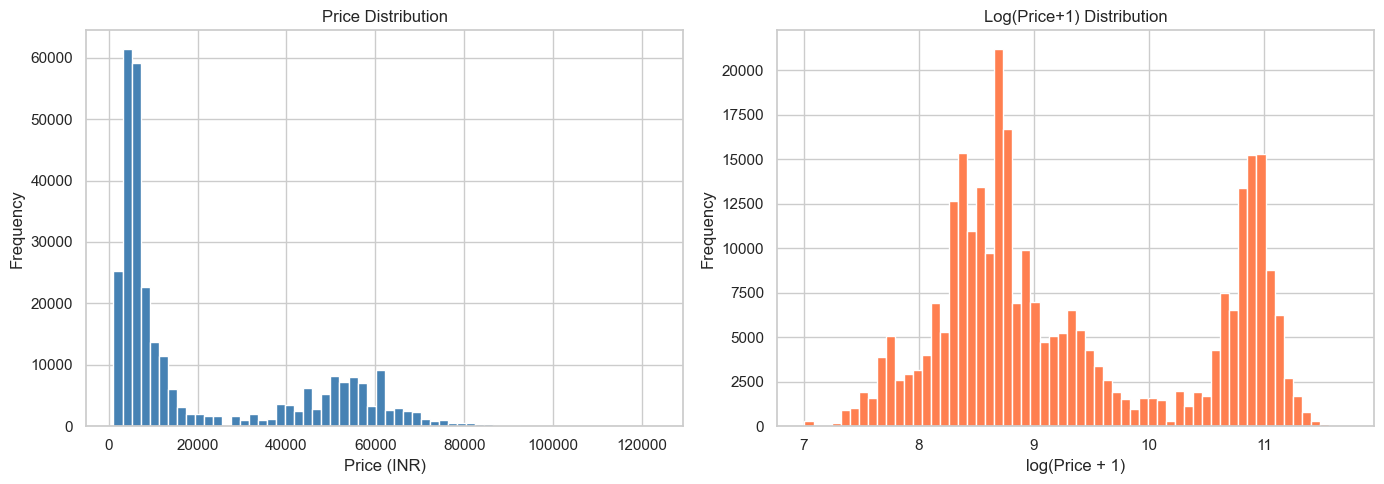

In [5]:
# Price distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['price'], bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Price Distribution')
axes[0].set_xlabel('Price (INR)')
axes[0].set_ylabel('Frequency')

axes[1].hist(np.log1p(df['price']), bins=60, color='coral', edgecolor='white')
axes[1].set_title('Log(Price+1) Distribution')
axes[1].set_xlabel('log(Price + 1)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

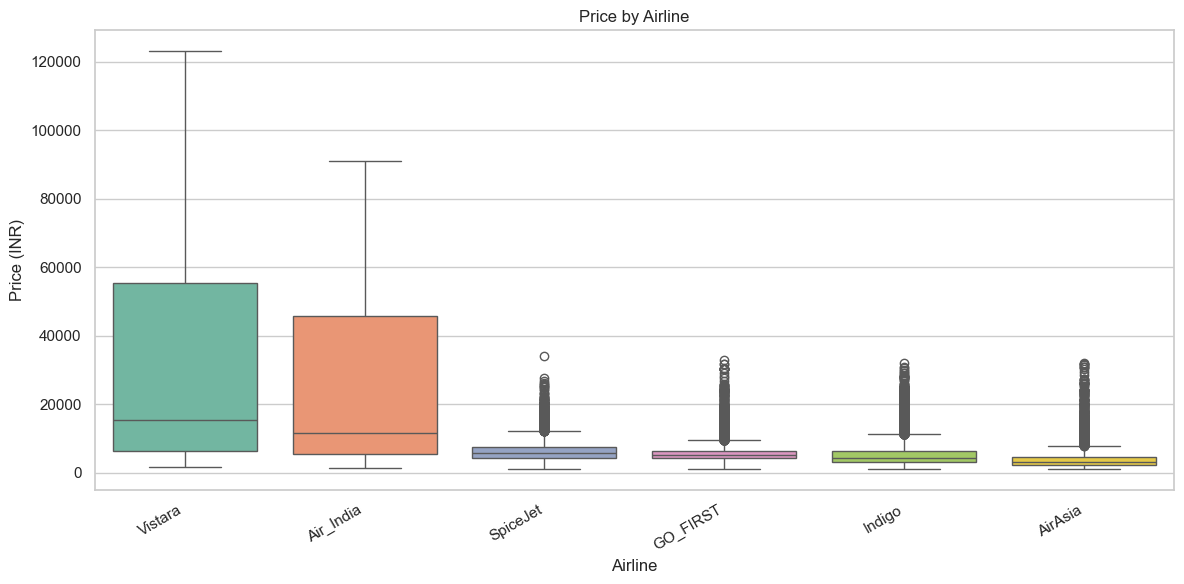

In [6]:
# Price by airline
plt.figure(figsize=(12, 6))
order = df.groupby('airline')['price'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='airline', y='price', order=order, palette='Set2')
plt.title('Price by Airline')
plt.xlabel('Airline')
plt.ylabel('Price (INR)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

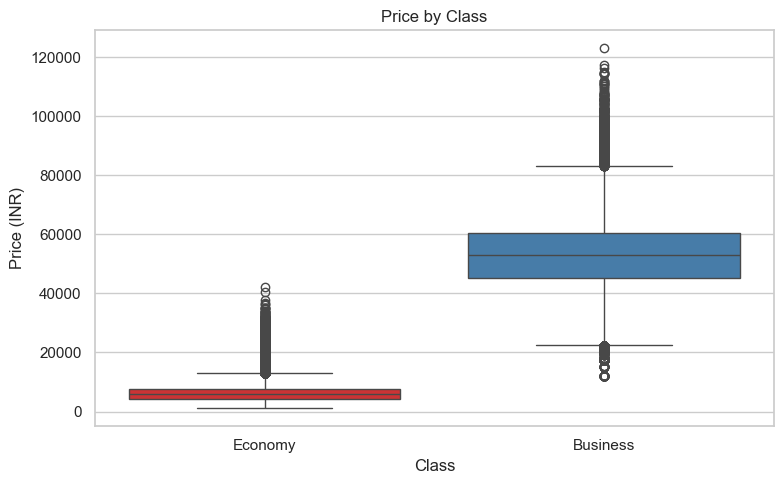

In [7]:
# Price by class
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='class', y='price', palette='Set1')
plt.title('Price by Class')
plt.xlabel('Class')
plt.ylabel('Price (INR)')
plt.tight_layout()
plt.show()

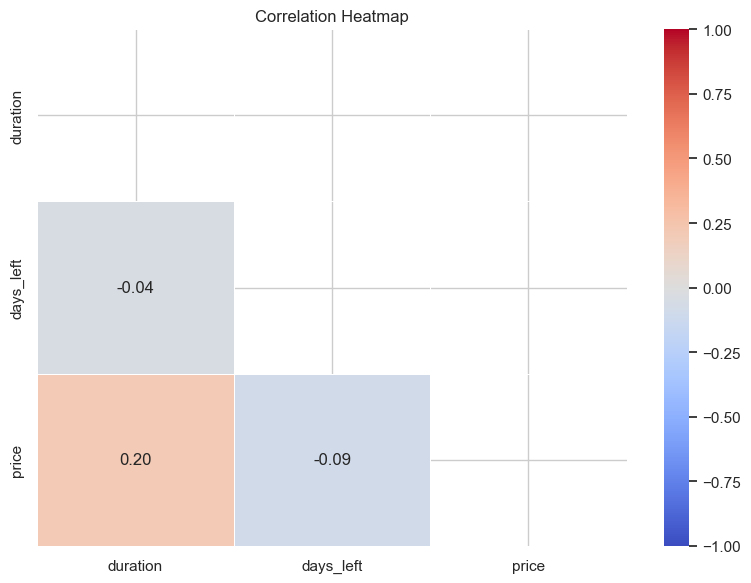

In [8]:
# Correlation heatmap (numeric columns only)
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

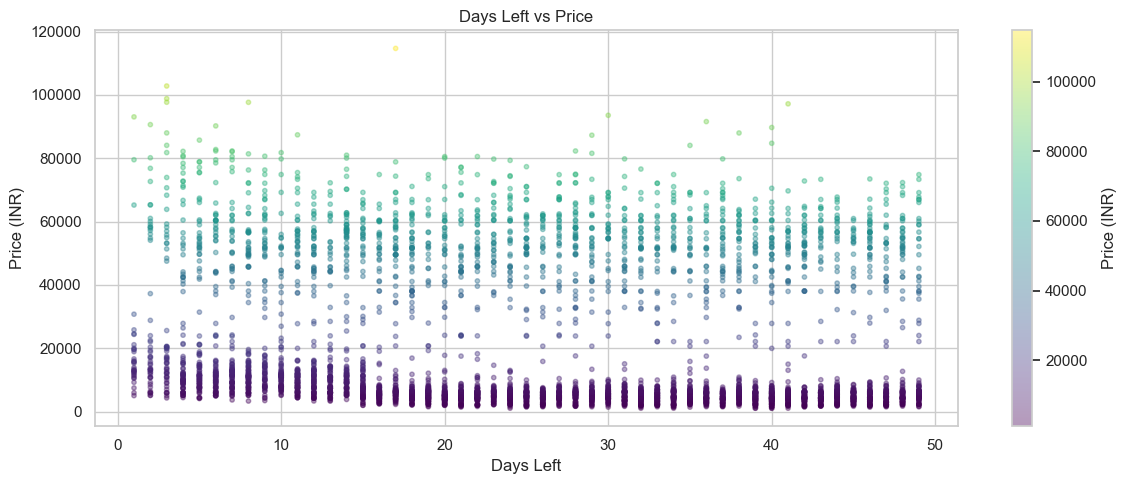

In [9]:
# Days left vs price scatter
plt.figure(figsize=(12, 5))
sample = df.sample(min(5000, len(df)), random_state=42)
scatter = plt.scatter(sample['days_left'], sample['price'],
                      c=sample['price'], cmap='viridis', alpha=0.4, s=10)
plt.colorbar(scatter, label='Price (INR)')
plt.title('Days Left vs Price')
plt.xlabel('Days Left')
plt.ylabel('Price (INR)')
plt.tight_layout()
plt.show()

---
## Section 2 — Feature Engineering

In [23]:
CATEGORICAL_COLS = ['airline', 'source_city', 'departure_time',
                    'stops', 'arrival_time', 'destination_city', 'class']
NUMERICAL_SCALE_COLS = ['duration', 'days_left']
TARGET_COL = 'price'

df_model = df.copy()

# Separate LabelEncoder per categorical column
encoders = {}
for col in CATEGORICAL_COLS:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    encoders[col] = le
    print(f'{col}: {len(le.classes_)} classes')

print('\nEncoders stored for:', list(encoders.keys()))

airline: 6 classes
source_city: 6 classes
departure_time: 6 classes
stops: 3 classes
arrival_time: 6 classes
destination_city: 6 classes
class: 2 classes

Encoders stored for: ['airline', 'source_city', 'departure_time', 'stops', 'arrival_time', 'destination_city', 'class']


In [24]:
# Scale only duration and days_left — NOT price
scaler = StandardScaler()
df_model[NUMERICAL_SCALE_COLS] = scaler.fit_transform(df_model[NUMERICAL_SCALE_COLS])

print('Scaled columns:', NUMERICAL_SCALE_COLS)
print('Price stats (unchanged):')
print(df_model[TARGET_COL].describe())

Scaled columns: ['duration', 'days_left']
Price stats (unchanged):
count    300153.000000
mean      20889.660523
std       22697.767366
min        1105.000000
25%        4783.000000
50%        7425.000000
75%       42521.000000
max      123071.000000
Name: price, dtype: float64


In [25]:
FEATURE_COLS = CATEGORICAL_COLS + NUMERICAL_SCALE_COLS
X = df_model[FEATURE_COLS]
y = df_model[TARGET_COL]

print('Features shape:', X.shape)
print('Target shape:', y.shape)
X.head()

Features shape: (300153, 9)
Target shape: (300153,)


,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left
0,4,2,2,2,5,5,1,-1.397531,-1.843875
1,4,2,1,2,4,5,1,-1.375284,-1.843875
2,0,2,1,2,1,5,1,-1.397531,-1.843875
3,5,2,4,2,0,5,1,-1.386407,-1.843875
4,5,2,4,2,4,5,1,-1.375284,-1.843875


---
## Section 3 — Model Training

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Train size: {X_train.shape[0]:,}  |  Test size: {X_test.shape[0]:,}')

Train size: 240,122  |  Test size: 60,031


In [27]:
model = RandomForestRegressor(
    n_estimators=50,
    max_depth=20,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)
print('Training complete.')

Training complete.


In [28]:
y_train_pred = model.predict(X_train)
y_test_pred  = model.predict(X_test)

train_r2 = r2_score(y_train, y_train_pred)
test_r2  = r2_score(y_test,  y_test_pred)

# Price is raw INR — no inverse transform needed
mae  = mean_absolute_error(y_test, y_test_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print(f'Train R²  : {train_r2:.4f}')
print(f'Test  R²  : {test_r2:.4f}')
print(f'MAE       : ₹{mae:,.2f}')
print(f'RMSE      : ₹{rmse:,.2f}')

Train R²  : 0.9872
Test  R²  : 0.9842
MAE       : ₹1,368.87
RMSE      : ₹2,851.23


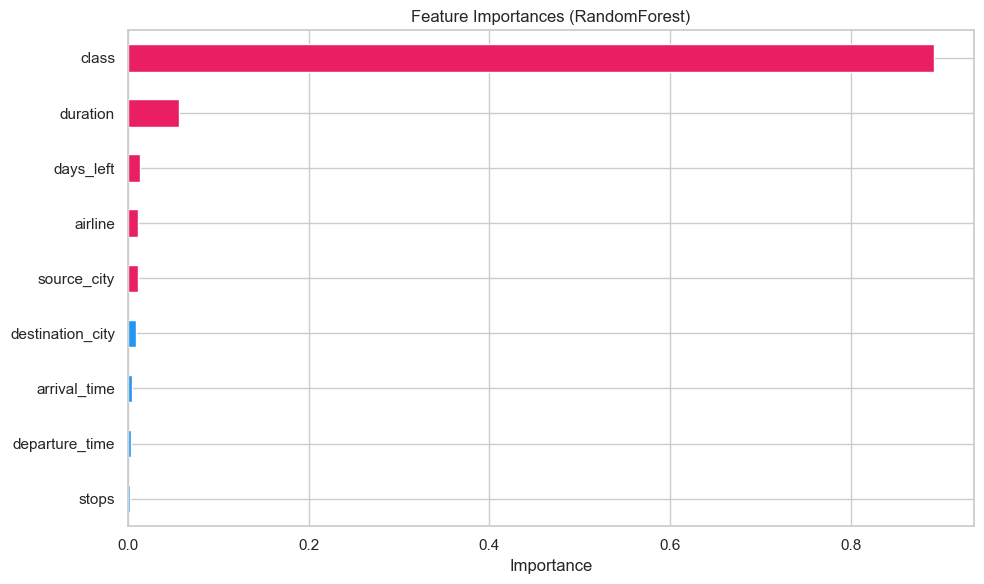


Top 5 features:
class          0.891953
duration       0.055786
days_left      0.012991
airline        0.010826
source_city    0.010372
dtype: float64


In [30]:
# Feature importance
importances = pd.Series(model.feature_importances_, index=FEATURE_COLS)
importances_sorted = importances.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
colors = ['#2196F3' if v < importances_sorted.median() else '#E91E63'
          for v in importances_sorted]
importances_sorted.plot(kind='barh', color=colors)
plt.title('Feature Importances (RandomForest)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print('\nTop 5 features:')
print(importances.sort_values(ascending=False).head())

---
## Section 4 — Save Artifacts

In [31]:
artifacts = {
    'model':    model,
    'encoders': encoders,   # dict of {col_name: LabelEncoder}
    'scaler':   scaler,     # fitted on [duration, days_left] only
    'feature_cols':        FEATURE_COLS,
    'categorical_cols':    CATEGORICAL_COLS,
    'numerical_scale_cols': NUMERICAL_SCALE_COLS,
}

save_path = '../data/model_artifacts_v2.pkl'
joblib.dump(artifacts, save_path, compress=3)

file_size_mb = os.path.getsize(save_path) / (1024 * 1024)
print(f'Saved to: {save_path}')
print(f'File size: {file_size_mb:.2f} MB')

Saved to: ../data/model_artifacts_v2.pkl
File size: 18.17 MB


In [32]:
# Sanity check — reload and predict one sample
loaded = joblib.load(save_path)
sample_input = X_test.iloc[[0]]
pred = loaded['model'].predict(sample_input)[0]
actual = y_test.iloc[0]
print(f'Reload check — Predicted: ₹{pred:,.0f}  |  Actual: ₹{actual:,.0f}')

Reload check — Predicted: ₹5,248  |  Actual: ₹7,366
